In [33]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# 1. Model Training

In [34]:
# 1. IMPORT LIBRARIES
import yfinance as yf
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 2. LOAD STOCK DATA
ticker = 'AAPL'
df = yf.download(ticker, start='2018-01-01', end='2023-12-31')

# Flatten column names to avoid MultiIndex issues with LightGBM
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] if col[1] == '' else f"{col[0]}_{col[1]}" for col in df.columns]

# 3. FEATURE ENGINEERING (using flattened column names)
close_col = 'Close_AAPL'  # or whatever the close column is called after flattening
df['return_5d'] = df[close_col].pct_change(5)
df['MA10'] = df[close_col].rolling(10).mean()
df['MA50'] = df[close_col].rolling(50).mean()
df['STD10'] = df[close_col].rolling(10).std()
df['RSI14'] = 100 - (100 / (1 + df[close_col].pct_change().rolling(14).apply(lambda x: (x[x > 0].mean() / abs(x[x < 0].mean())) if len(x[x < 0]) > 0 else 1)))
df.dropna(inplace=True)

# to change:
df['ROC_10'] = df[close_col].pct_change(periods=10)
df['EMA10'] = df[close_col].ewm(span=10).mean()

ema12 = df[close_col].ewm(span=12).mean()
ema26 = df[close_col].ewm(span=26).mean()
df['MACD'] = ema12 - ema26


# 4. CREATE LABEL
df['target'] = np.where(df['return_5d'].shift(-5) > 0, 1, 0)

# 5. SELECT FEATURES & TARGET
features = ['MA10', 'MA50', 'STD10', 'RSI14', 'ROC_10', 'EMA10', 'MACD']
X = df[features]
y = df['target']

# 6. TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 7. TRAIN LIGHTGBM MODEL
train_data = lgb.Dataset(X_train, label=y_train)
params = {
    'objective': 'binary',
    'metric': 'binary_error',
    'verbosity': -1
}
model = lgb.train(params, train_data)

# 8. PREDICT & EVALUATE
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.2%}')

# 9. ADD SIGNAL COLUMN
df.loc[X_test.index, 'prediction'] = y_pred

[*********************100%***********************]  1 of 1 completed


Model Accuracy: 41.10%


benchmark换一下，因子要多一点，止损slippage等要改

<Axes: title={'center': 'AAPL Price vs Model Prediction'}, xlabel='Date'>

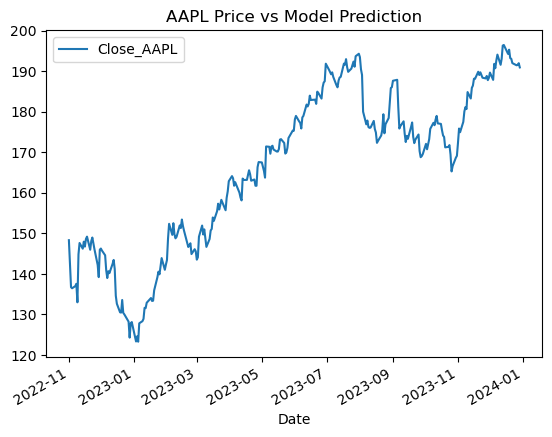

In [35]:
df.loc[X_test.index, ['Close_AAPL']].plot(title="AAPL Price vs Model Prediction")

# 2. Backtest

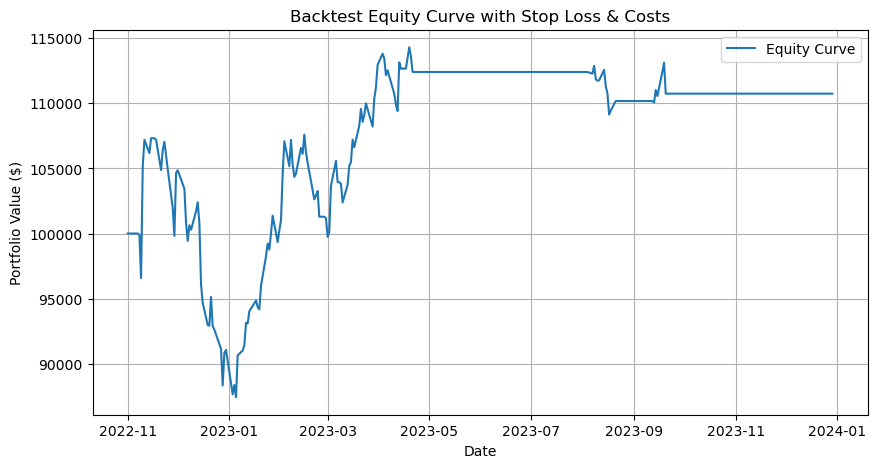

Final Portfolio Value: $110,744.17
Total Return: 10.74%


In [36]:
import matplotlib.pyplot as plt

# 10. BACKTESTING STRATEGY WITH STOP LOSS AND COSTS
initial_cash = 100000
cash = initial_cash
position = 0
holding_days = 0
equity_curve = []

# use test portion of data
test_df = df.loc[X_test.index].copy()
test_df.reset_index(inplace=True)

# constants
TRANSACTION_FEE_RATE = 0.001   # 0.1% per trade
SLIPPAGE_RATE = 0.0001          # 0.1% per trade
STOP_LOSS_PCT = 0.2           # 5% stop loss，比如两倍波动率

for i in range(len(test_df)):
    price_today = test_df.loc[i, close_col]

    # if in a trade
    if position > 0:
        holding_days -= 1
        
        # calculate unrealized PnL
        market_value = position * price_today
        current_equity = cash + market_value

        # stop loss trigger
        if price_today < entry_price * (1 - STOP_LOSS_PCT):
            # sell at price with slippage & fees
            exit_price = price_today * (1 - SLIPPAGE_RATE)
            cash = position * exit_price * (1 - TRANSACTION_FEE_RATE)
            position = 0
            holding_days = 0
        # normal exit after holding period
        elif holding_days == 0:
            exit_price = price_today * (1 - SLIPPAGE_RATE)
            cash = position * exit_price * (1 - TRANSACTION_FEE_RATE)
            position = 0
        # else just continue holding

    # if not in a trade
    if position == 0:
        if test_df.loc[i, 'prediction'] == 1:
            # buy at price with slippage & fees
            entry_price = price_today * (1 + SLIPPAGE_RATE)
            position = cash / (entry_price * (1 + TRANSACTION_FEE_RATE))
            cash = 0
            holding_days = 5  # hold 5 days

    # calculate current total equity
    equity = cash + position * price_today
    equity_curve.append(equity)

# plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(test_df['Date'], equity_curve, label='Equity Curve')
plt.title('Backtest Equity Curve with Stop Loss & Costs')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid()
plt.show()

# final stats
final_value = equity_curve[-1]
total_return = (final_value - initial_cash) / initial_cash
print(f"Final Portfolio Value: ${final_value:,.2f}")
print(f"Total Return: {total_return:.2%}")


In [37]:
import numpy as np

# convert equity curve to numpy array
equity_curve = np.array(equity_curve)

# calculate daily returns of portfolio
portfolio_returns = np.diff(equity_curve) / equity_curve[:-1]

# drawdown calculation
equity_peak = np.maximum.accumulate(equity_curve)
drawdown = (equity_curve - equity_peak) / equity_peak
max_drawdown = drawdown.min()

# sharpe ratio calculation
average_return = portfolio_returns.mean()
return_std = portfolio_returns.std()
sharpe_ratio = average_return / return_std * np.sqrt(252)  # annualized

# print results
print(f"Maximum Drawdown: {max_drawdown:.2%}")
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


Maximum Drawdown: -18.54%
Annualized Sharpe Ratio: 0.57


# Regression

Training until validation scores don't improve for 50 rounds
[50]	training's rmse: 0.0211241	valid_1's rmse: 0.0269984
Early stopping, best iteration is:
[21]	training's rmse: 0.0264001	valid_1's rmse: 0.0253971
Final Portfolio Value: $106,772.22
Total Return: 6.77%
Maximum Drawdown: -7.26%
Annualized Sharpe Ratio: 2.41


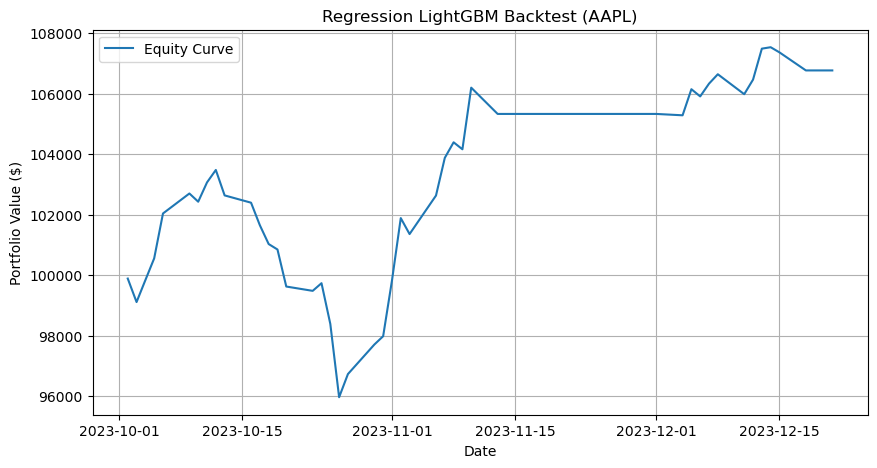

In [38]:
# ====== LightGBM regression + threshold + position sizing backtest ======

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1) BUILD REGRESSION TARGET (5-day forward pct change)
HOLD_DAYS = 5
df['target_reg'] = df[close_col].shift(-HOLD_DAYS) / df[close_col] - 1
df.dropna(inplace=True)  # drop rows with NaNs introduced by shifts/rolling

# 2) FEATURES & TARGET (rebuild X, y to match df after dropna)
features = ['MA10', 'MA50', 'STD10', 'RSI14', 'ROC_10', 'EMA10', 'MACD']  # adjust as you wish
X = df[features]
y = df['target_reg']

# 3) TRAIN/TEST SPLIT (time-series split: no shuffle)
test_size = 0.2
split_idx = int(len(X) * (1 - test_size))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
df_test = df.iloc[split_idx:].copy().reset_index()  # for backtest dates/prices

# 4) TRAIN LightGBM as regressor
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}

lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_eval  = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_train, lgb_eval],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50)  # optional logging
    ]
)

# 5) PREDICT on test set
predicted = model.predict(X_test)  # predicted 5-day returns
df_test['predicted_return'] = predicted  # align predictions with df_test rows

# 6) TRADING RULE PARAMETERS
THRESHOLD = 0.007         # only take trades when predicted 5-day return > 0.7%
MAX_HOLD_DAYS = HOLD_DAYS # hold for 5 days unless stop loss triggers
TRANSACTION_FEE_RATE = 0.001
SLIPPAGE_RATE = 0.0001
STOP_LOSS_PCT = 0.2      # 5% stop loss
# position sizing: scale predicted_return to a fraction of cash
# predicted 2% => full size, 1% => 50% size, etc. Adjust SCALE_FOR_FULL to tune
SCALE_FOR_FULL = 0.02

# 7) BACKTEST LOOP (one trade at a time, fractional sized)
initial_cash = 100000.0
cash = initial_cash
position_shares = 0.0
entry_price = None
holding_days = 0
equity_curve = []
positions_record = []

for i in range(len(df_test)):
    price_today = df_test.loc[i, close_col]
    pred_ret = df_test.loc[i, 'predicted_return']

    # 1) check stop-loss if in position
    if position_shares > 0:
        market_value = position_shares * price_today
        # stop loss check (based on the entry price)
        if price_today < entry_price * (1 - STOP_LOSS_PCT):
            # sell at price with slippage & fees
            exit_price = price_today * (1 - SLIPPAGE_RATE)
            proceeds = position_shares * exit_price
            proceeds_after_fee = proceeds * (1 - TRANSACTION_FEE_RATE)
            cash += proceeds_after_fee
            position_shares = 0.0
            entry_price = None
            holding_days = 0
        else:
            holding_days -= 1
            # normal exit after holding period
            if holding_days <= 0:
                exit_price = price_today * (1 - SLIPPAGE_RATE)
                proceeds = position_shares * exit_price
                proceeds_after_fee = proceeds * (1 - TRANSACTION_FEE_RATE)
                cash += proceeds_after_fee
                position_shares = 0.0
                entry_price = None
                holding_days = 0

    # 2) if not in position, consider entering
    if position_shares == 0:
        if pred_ret > THRESHOLD:
            # compute position fraction based on prediction magnitude
            frac = np.clip(pred_ret / SCALE_FOR_FULL, 0.0, 1.0)
            # if frac is tiny, skip
            if frac > 0.0:
                budget = cash * frac
                buy_price = price_today * (1 + SLIPPAGE_RATE)
                # buy shares; account for transaction fee as a reduction in budget too
                # simplest: buy shares = budget / buy_price, then subtract fee from cash on buy
                shares = budget / buy_price
                cash -= budget  # reserve budget used for buying
                # apply transaction fee on the notional bought (more realistic)
                fee = (shares * buy_price) * TRANSACTION_FEE_RATE
                cash -= fee
                # record position
                position_shares = shares
                entry_price = buy_price
                holding_days = MAX_HOLD_DAYS

    # 3) compute equity and save
    equity = cash + position_shares * price_today
    equity_curve.append(equity)
    positions_record.append({
        'date': df_test.loc[i, 'Date'],
        'price': price_today,
        'predicted_return': pred_ret,
        'cash': cash,
        'shares': position_shares,
        'equity': equity
    })

# 8) METRICS: returns, drawdown, sharpe
equity_curve = np.array(equity_curve)
portfolio_returns = np.diff(equity_curve) / equity_curve[:-1]
equity_peak = np.maximum.accumulate(equity_curve)
drawdown = (equity_curve - equity_peak) / equity_peak
max_drawdown = drawdown.min()

# annualized Sharpe (assume daily returns, 252 trading days)
avg_daily_ret = np.nanmean(portfolio_returns)
std_daily_ret = np.nanstd(portfolio_returns)
sharpe = (avg_daily_ret / std_daily_ret) * np.sqrt(252) if std_daily_ret != 0 else np.nan

final_value = equity_curve[-1]
total_return = (final_value - initial_cash) / initial_cash

# 9) OUTPUT & PLOT
print(f"Final Portfolio Value: ${final_value:,.2f}")
print(f"Total Return: {total_return:.2%}")
print(f"Maximum Drawdown: {max_drawdown:.2%}")
print(f"Annualized Sharpe Ratio: {sharpe:.2f}")

# plot equity
plt.figure(figsize=(10,5))
plt.plot([r['date'] for r in positions_record], equity_curve, label='Equity Curve')
plt.title('Regression LightGBM Backtest (AAPL)')
plt.xlabel('Date'); plt.ylabel('Portfolio Value ($)')
plt.grid(True); plt.legend()
plt.show()
